In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("train.csv")

In [3]:
x = data.drop("financial_stress_level",axis=1)
y = data["financial_stress_level"]

In [4]:
x.drop("Unnamed: 0",axis=1,inplace=True)
y_map = {"Moderate": 1, "High": 2, "Low": 0}
y = y.map(y_map)

In [5]:
x[14:21]

,worker_id,survey_month,worker_age,job_sector,estimated_annual_income,monthly_gig_income,num_savings_accounts,num_credit_cards,avg_credit_interest,num_active_loans,avg_loan_delay_days,missed_payment_events,recent_credit_checks,current_total_liability,credit_utilization_rate,credit_age_months,min_payment_flag,monthly_investments,spending_behavior,end_of_month_balance
14,55f99d4113,February,21.0,Developer,NaN,2849.099167,7,5,5.0,0.0,5,NaN,4.0,943.86,39.797764,30 y. 8 m.,Yes,276.725394,NaN,283.825522
15,55f99d4113,March,21.0,Developer,35116.14,NaN,7,5,5.0,0.0,9,NaN,4.0,943.86,27.020360,30 y. 9 m.,NM,74.443641,"Large expenses, medium payments",451.967276
16,55f99d4113,April,21.0,Developer,34566.50,2822.499167,7,5,5.0,NaN,5,12.0,4.0,943.86,23.462303,30 y. 10 m.,Yes,173.138651,"Small expenses, medium payments",383.772266
17,55f99d4113,May,21.0,Developer,35165.35,2784.859167,7,5,5.0,0.0,1,15.0,4.0,943.86,28.924954,30 y. 11 m.,Yes,96.785485,"Large expenses, medium payments",433.995432
18,55f99d4113,June,21.0,Developer,35159.81,2821.959167,7,5,5.0,0.0,9,17.0,4.0,943.86,41.776187,31 y. 0 m.,Yes,62.723278,"Large expenses, small payments",477.847638
19,55f99d4113,July,21.0,Developer,35164.64,NaN,7,5,5.0,NaN,5,15.0,4.0,943.86,29.217556,31 y. 1 m.,Yes,37.643638,"Large expenses, medium payments",494.067279
20,55f99d4113,August,21.0,Developer,35491.46,2755.139167,7,5,5.0,0.0,10,15.0,4.0,943.86,26.263823,31 y. 2 m.,Yes,181.011983,"Small expenses, small payments",388.328934


In [6]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   worker_id                56000 non-null  str    
 1   survey_month             56000 non-null  str    
 2   worker_age               51726 non-null  float64
 3   job_sector               52017 non-null  str    
 4   estimated_annual_income  52076 non-null  float64
 5   monthly_gig_income       47604 non-null  float64
 6   num_savings_accounts     56000 non-null  int64  
 7   num_credit_cards         56000 non-null  int64  
 8   avg_credit_interest      54007 non-null  float64
 9   num_active_loans         50926 non-null  float64
 10  avg_loan_delay_days      56000 non-null  int64  
 11  missed_payment_events    49731 non-null  float64
 12  recent_credit_checks     53813 non-null  float64
 13  current_total_liability  55443 non-null  float64
 14  credit_utilization_rate  56000 no

In [7]:
x.describe()

,worker_age,estimated_annual_income,monthly_gig_income,num_savings_accounts,num_credit_cards,avg_credit_interest,num_active_loans,avg_loan_delay_days,missed_payment_events,recent_credit_checks,current_total_liability,credit_utilization_rate,monthly_investments,end_of_month_balance
count,51726.000000,5.207600e+04,47604.000000,56000.000000,56000.000000,54007.000000,50926.000000,56000.000000,49731.000000,53813.000000,55443.000000,56000.000000,51080.000000,55302.000000
mean,33.239125,1.847764e+05,4144.940613,16.906054,22.505857,14.250014,3.518399,20.931179,13.400394,5.627544,1418.509080,32.257797,196.081579,397.835424
std,10.784547,1.495797e+06,3199.911242,116.311458,129.614382,8.486129,2.456607,14.787599,6.240864,3.793041,1158.188602,5.130267,201.156252,213.612536
min,14.000000,6.035990e+03,204.485417,-1.000000,1.000000,0.500000,0.000000,-6.000000,0.000000,0.000000,0.230000,20.000000,0.000000,0.007760
25%,24.000000,1.892614e+04,1572.005108,3.000000,4.000000,7.000000,2.000000,10.000000,9.000000,3.000000,555.880000,28.001990,72.140163,264.939289
50%,33.000000,3.671124e+04,3028.468333,6.000000,6.000000,13.000000,3.000000,18.000000,14.000000,5.000000,1163.470000,32.279565,128.954291,331.802908
75%,42.000000,7.271873e+04,5919.943333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,8.000000,1922.820000,36.476202,237.305018,464.525826
max,115.000000,2.419779e+07,15202.263333,1798.000000,1499.000000,33.500000,9.000000,69.000000,28.000000,16.000000,4997.100000,50.000000,1961.218850,1592.580519


In [8]:
m = x[["worker_id","credit_age_months","monthly_gig_income","survey_month","estimated_annual_income"]]

In [9]:
x[["spending_behav_expense","spending_behav_payment"]] = (x["spending_behavior"].str.split(",",expand= True))
x.spending_behav_payment= x.spending_behav_payment.str.strip()
x.spending_behav_payment.value_counts()
mapping_spending = {
    "small payments" : 0,
    "medium payments" : 1,
    "large payments" : 2,

    "Small expenses" :0,
    "Large expenses" : 1
}
x.spending_behav_payment = x.spending_behav_payment.map(mapping_spending)
x.spending_behav_expense = x.spending_behav_expense.map(mapping_spending)

In [10]:
mapping_payment_flag = {
    "No" : 0,
    "Yes" : 1,
    "NM" : np.nan
}
x["min_payment_flag"] = x["min_payment_flag"].map(mapping_payment_flag)

In [11]:
h = (
    x['credit_age_months']
    .str.extract(r'(\d+)\s*y\.\s*(\d+)\s*m\.')
    .astype(float)
)
x.credit_age_months = h[0]+h[1]/12

In [12]:
x['job_sector'] = (
    x.groupby('worker_id')['job_sector']
    .transform(lambda col: col.ffill().bfill())
)

In [13]:
month_order = {
    'January':1,
    'February':2,
    'March':3,
    'April':4,
    'May':5,
    'June':6,
    'July':7,
    'August':8,
    'September':9,
    'October':10,
    'November':11,
    'December':12
}
x.survey_month = x.survey_month.map(month_order)

In [14]:
train_months = [
    "February", "March", "April", "May", "June", "July"
]

val_month = ["August"]

train_mask = data["survey_month"].isin(train_months)
val_mask = x["survey_month"].eq(8)

X_train = x.loc[train_mask].drop(columns=["financial_stress_level"], errors="ignore")
y_train = y.loc[train_mask]

X_valid = x.loc[val_mask].drop(columns=["financial_stress_level"], errors="ignore")
y_valid = y.loc[val_mask]

In [15]:
# m.groupby("worker_id").num_savings_accounts.min()
X_train.info()

<class 'pandas.DataFrame'>
Index: 48000 entries, 0 to 55998
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   worker_id                48000 non-null  str    
 1   survey_month             48000 non-null  int64  
 2   worker_age               44297 non-null  float64
 3   job_sector               48000 non-null  str    
 4   estimated_annual_income  44608 non-null  float64
 5   monthly_gig_income       40755 non-null  float64
 6   num_savings_accounts     48000 non-null  int64  
 7   num_credit_cards         48000 non-null  int64  
 8   avg_credit_interest      46306 non-null  float64
 9   num_active_loans         43650 non-null  float64
 10  avg_loan_delay_days      48000 non-null  int64  
 11  missed_payment_events    42586 non-null  float64
 12  recent_credit_checks     46145 non-null  float64
 13  current_total_liability  47528 non-null  float64
 14  credit_utilization_rate  48000 non-nul

In [16]:
X_train.loc[x['num_credit_cards'] > 10,'num_credit_cards']= np.nan
X_train['num_credit_cards'] = (X_train.groupby('worker_id')['num_credit_cards'].transform(lambda col: col.fillna(col.median())))



X_train.loc[x['num_savings_accounts'] > 10,'num_savings_accounts']= np.nan
X_train['num_savings_accounts'] = (X_train.groupby('worker_id')['num_savings_accounts'].transform(lambda col: col.fillna(col.median())))
X_train.loc[x.num_savings_accounts==-1,"num_savings_accounts"] = 0


In [17]:
worker_median = (
    X_train.groupby('worker_id')['estimated_annual_income']
    .transform('median')
)

ratio = (
    x['estimated_annual_income'] /
    (worker_median + 1)
)

# rows that are suspiciously large
outlier_mask = ratio > 3.5

# convert outliers to NaN
X_train.loc[
    outlier_mask,
    'estimated_annual_income'
] = np.nan

In [18]:
X_train['estimated_annual_income'] = (
    X_train.groupby('worker_id')['estimated_annual_income']
    .transform(lambda c: c.fillna(c.median()))
)

In [19]:


X_train['month_num'] = X_train['survey_month'].map(month_order)
X_train = X_train.sort_values(['worker_id', 'month_num'])


In [20]:
X_train.loc[x['worker_age'] > 90,'worker_age'] = np.nan
X_train["worker_age"] = (
    X_train.groupby('worker_id')['worker_age']
    .transform(lambda col: col.fillna(col.median()))
)

In [21]:
X_train['monthly_gig_income'] = (
    X_train.groupby('worker_id')['monthly_gig_income']
    .transform(lambda c: c.fillna(c.median()))
)

In [22]:
def fill_credit_age(group):
    group = group.copy()

    known = group.dropna(subset=['credit_age_months'])

    if known.empty:
        return group

    for idx in group[group['credit_age_months'].isna()].index:
        current_month = group.loc[idx, 'survey_month']

        nearest_idx = (known['survey_month'] - current_month).abs().idxmin()

        nearest_month = known.loc[nearest_idx, 'survey_month']
        nearest_age = known.loc[nearest_idx, 'credit_age_months']

        month_diff = current_month - nearest_month

        group.loc[idx, 'credit_age_months'] = nearest_age + month_diff/12

    return group

In [23]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 48000 entries, 13125 to 14712
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   worker_id                48000 non-null  str    
 1   survey_month             48000 non-null  int64  
 2   worker_age               48000 non-null  float64
 3   job_sector               48000 non-null  str    
 4   estimated_annual_income  48000 non-null  float64
 5   monthly_gig_income       48000 non-null  float64
 6   num_savings_accounts     48000 non-null  float64
 7   num_credit_cards         48000 non-null  float64
 8   avg_credit_interest      46306 non-null  float64
 9   num_active_loans         43650 non-null  float64
 10  avg_loan_delay_days      48000 non-null  int64  
 11  missed_payment_events    42586 non-null  float64
 12  recent_credit_checks     46145 non-null  float64
 13  current_total_liability  47528 non-null  float64
 14  credit_utilization_rate  48000 non

In [24]:
X_train["target"] = y_train

filled_groups = []

for _, group in X_train.groupby("worker_id"):
    group = fill_credit_age(group)
    filled_groups.append(group)

X_train = pd.concat(filled_groups, ignore_index=True)

y_train = X_train["target"]
X_train = X_train.drop(columns=["target"])

In [25]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   worker_id                48000 non-null  str    
 1   survey_month             48000 non-null  int64  
 2   worker_age               48000 non-null  float64
 3   job_sector               48000 non-null  str    
 4   estimated_annual_income  48000 non-null  float64
 5   monthly_gig_income       48000 non-null  float64
 6   num_savings_accounts     48000 non-null  float64
 7   num_credit_cards         48000 non-null  float64
 8   avg_credit_interest      46306 non-null  float64
 9   num_active_loans         43650 non-null  float64
 10  avg_loan_delay_days      48000 non-null  int64  
 11  missed_payment_events    42586 non-null  float64
 12  recent_credit_checks     46145 non-null  float64
 13  current_total_liability  47528 non-null  float64
 14  credit_utilization_rate  48000 no

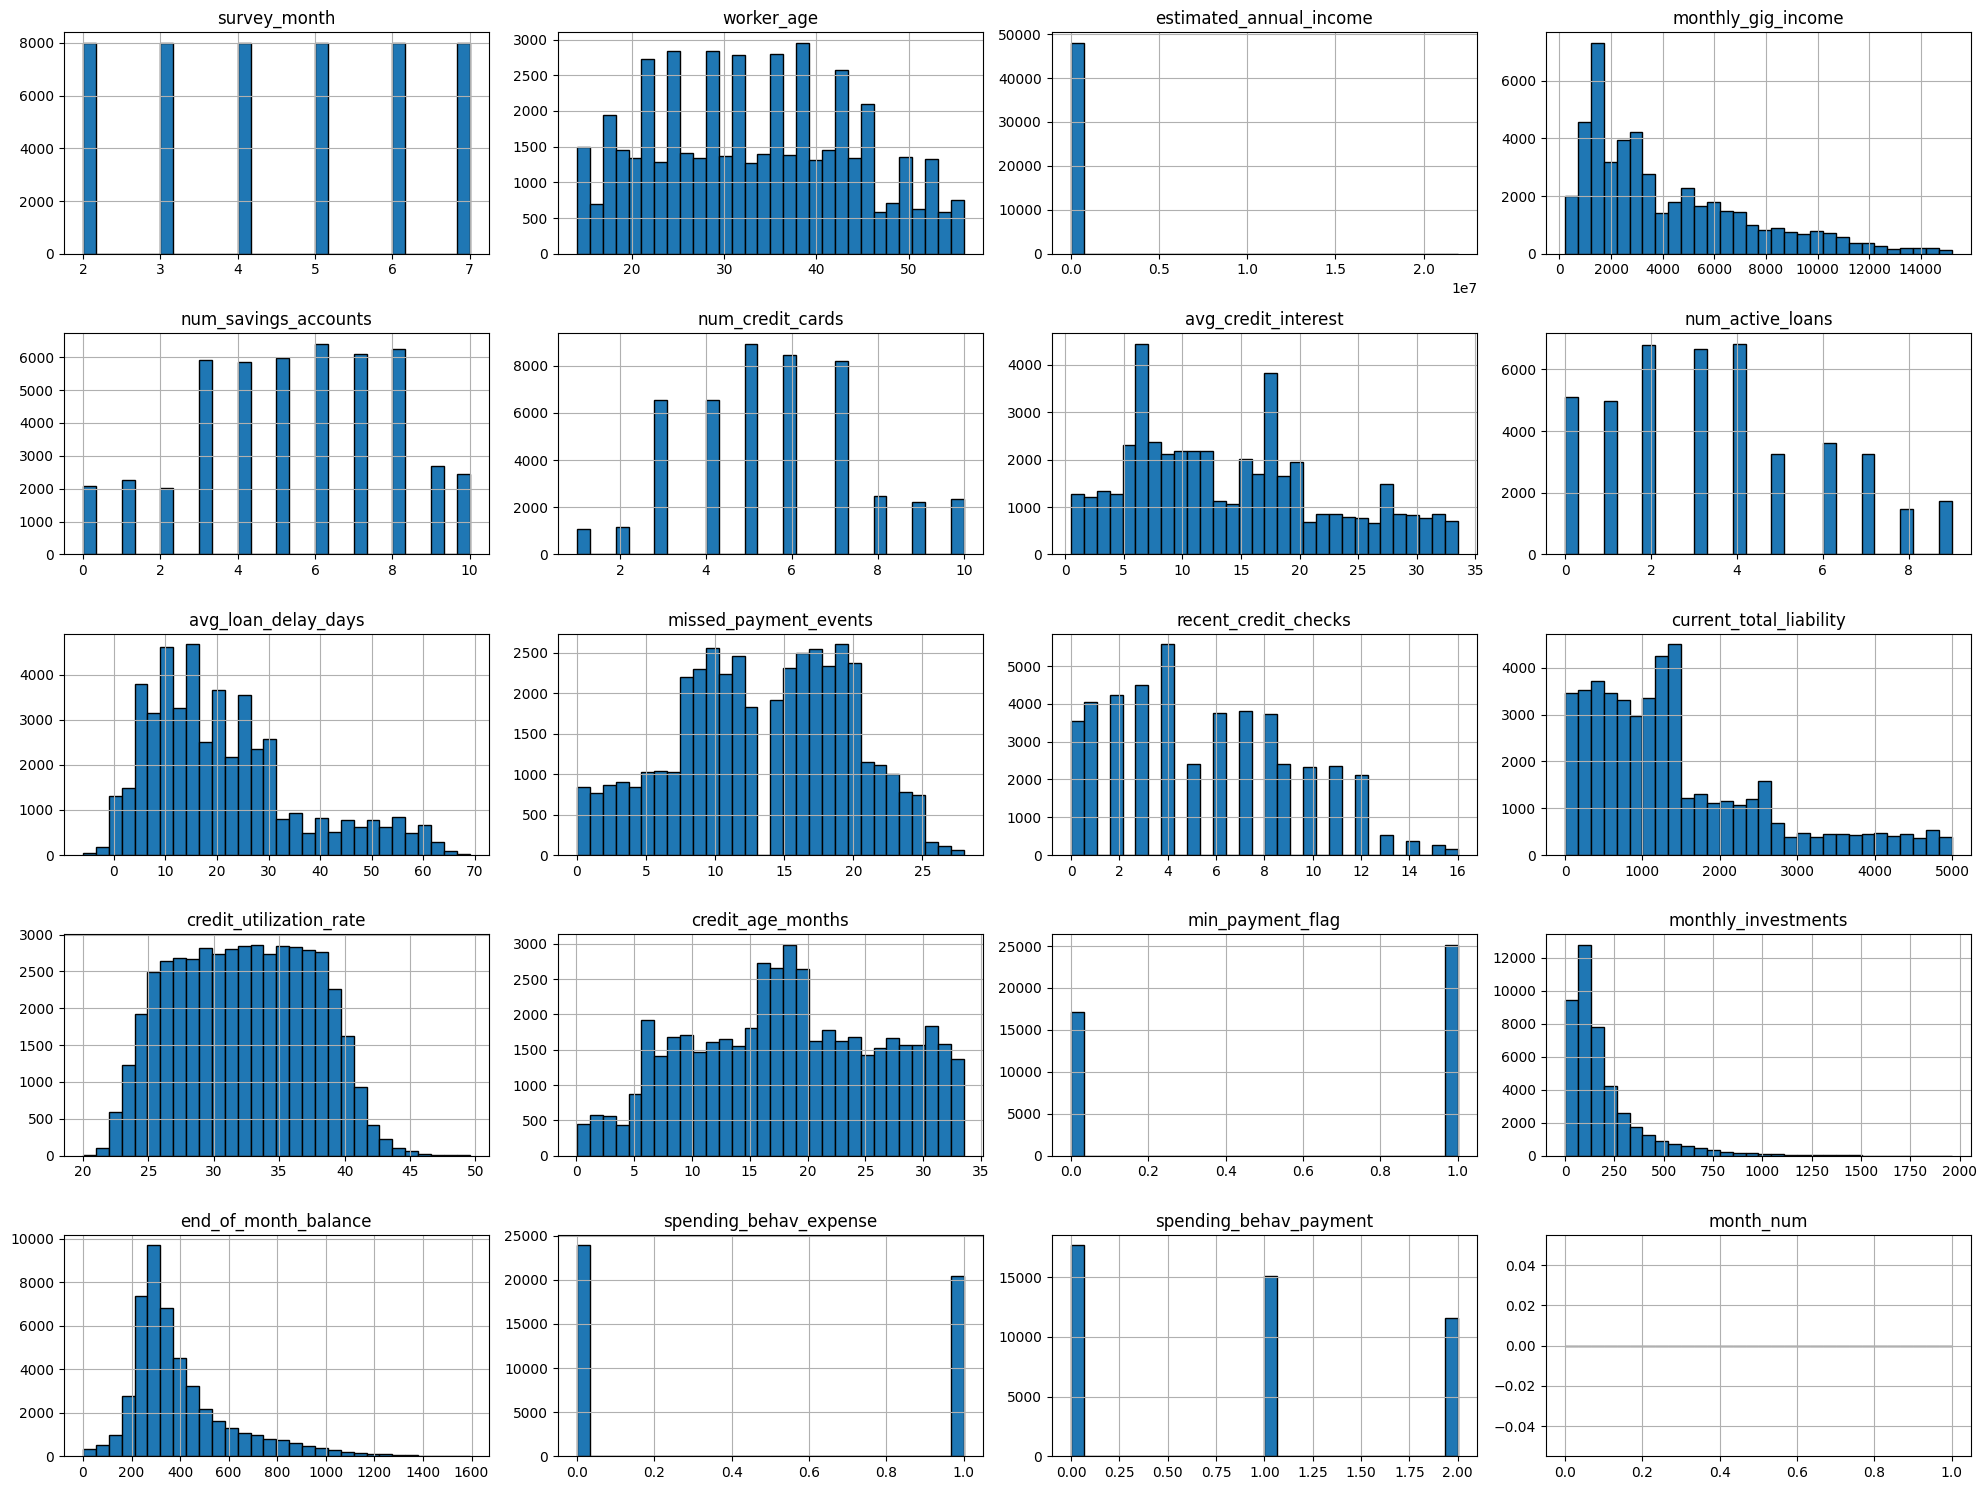

In [26]:
import matplotlib.pyplot as plt

X_train.hist(
    figsize=(20, 15),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

In [27]:
# # x.drop("worker_id_copy",axis=1,inplace=Trueworker_id_copy)
# x.insert(0,"worker_id",n)

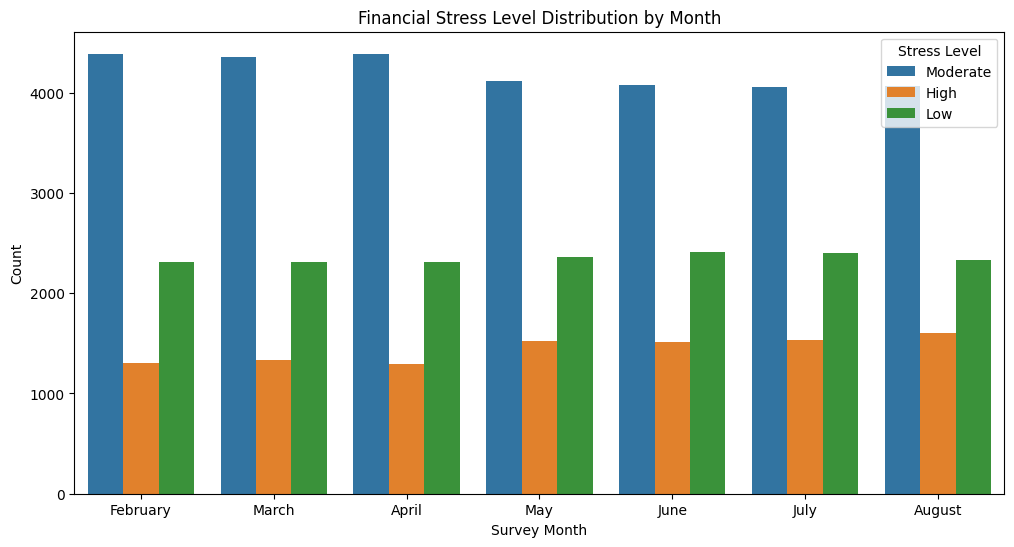

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x='survey_month',
    hue='financial_stress_level'
)

plt.title("Financial Stress Level Distribution by Month")
plt.xlabel("Survey Month")
plt.ylabel("Count")

plt.legend(title="Stress Level")

plt.show()

In [29]:
X_train.head(7)

,worker_id,survey_month,worker_age,job_sector,estimated_annual_income,monthly_gig_income,num_savings_accounts,num_credit_cards,avg_credit_interest,num_active_loans,...,current_total_liability,credit_utilization_rate,credit_age_months,min_payment_flag,monthly_investments,spending_behavior,end_of_month_balance,spending_behav_expense,spending_behav_payment,month_num
0,0016d1b737,2,36.0,Architect,119835.26,10157.6025,1.0,3.0,6.0,1.0,...,489.86,29.480531,16.416667,0.0,755.132399,"Small expenses, small payments",476.346124,0.0,0.0,NaN
1,0016d1b737,3,36.0,Architect,119862.86,10105.4025,1.0,3.0,6.0,1.0,...,489.86,43.097420,16.500000,0.0,217.475330,"Large expenses, large payments",968.413193,1.0,2.0,NaN
2,0016d1b737,4,36.0,Architect,119143.58,10150.3725,1.0,3.0,6.0,1.0,...,489.86,40.765860,16.583333,0.0,670.091195,"Small expenses, medium payments",554.297329,0.0,1.0,NaN
3,0016d1b737,5,36.0,Architect,119750.79,10124.5425,1.0,3.0,6.0,1.0,...,489.86,29.735696,16.666667,0.0,1258.433440,"Small expenses, small payments",NaN,0.0,0.0,NaN
4,0016d1b737,6,37.0,Architect,119010.97,10132.5025,1.0,3.0,6.0,1.0,...,489.86,44.330831,16.750000,0.0,234.593027,"Large expenses, large payments",943.655496,1.0,2.0,NaN
5,0016d1b737,7,37.0,Architect,119338.62,10114.8125,1.0,3.0,6.0,1.0,...,489.86,40.203795,16.833333,0.0,408.703857,"Small expenses, medium payments",811.644667,0.0,1.0,NaN
6,001e73ed67,2,36.0,Lawyer,124501.89,10099.3625,4.0,3.0,9.0,0.0,...,1344.09,32.658223,15.750000,0.0,104.840871,NaN,1151.205379,NaN,NaN,NaN


In [30]:
X_train.loc[x["estimated_annual_income"]>200000,["survey_month","worker_id","estimated_annual_income"]]

,survey_month,worker_id,estimated_annual_income
162,2,00dd25ce0f,10260.395
171,5,00dfbc288d,12183.345
291,5,017f24dc3b,19810.980
330,2,01e1136456,17618.350
691,3,03b9ea64b1,41835.750
...,...,...,...
47617,3,fd938658df,15663.480
47652,2,fdba0074c1,142748.270
47873,7,fec165f3d8,77135.610
47901,5,ff2451fffb,16913.700


In [31]:
X_train.loc[x["worker_id"]=="26536b7a86",["survey_month","worker_id","estimated_annual_income","num_savings_accounts"]]

,survey_month,worker_id,estimated_annual_income,num_savings_accounts
25620,2,87ecc2c37f,121381.430,7.0
25621,3,87ecc2c37f,121565.500,7.0
25622,4,87ecc2c37f,122028.380,7.0
25623,5,87ecc2c37f,121592.140,7.0
25624,6,87ecc2c37f,121565.500,7.0
25625,7,87ecc2c37f,121211.510,7.0
25626,2,87edda03e0,14338.785,0.0


In [32]:
mo = X_train.groupby("worker_id")['estimated_annual_income'].describe(percentiles=[0.4,0.3,0.5,0.6,0.75,0.90,0.95,0.975,0.99,0.999])

In [33]:
mo

,count,mean,std,min,30%,40%,50%,60%,75%,90%,95%,97.5%,99%,99.9%,max
worker_id,,,,,,,,,,,,,,,
0016d1b737,6.0,119490.346667,373.800003,119010.970,119241.100,119338.620,119544.705,119750.790,119814.1425,119849.060,119855.9600,119859.41000,119861.4800,119862.72200,119862.860
001e73ed67,6.0,124540.453333,154.244458,124376.330,124457.040,124501.890,124501.890,124501.890,124634.5050,124725.210,124748.4600,124760.08500,124767.0600,124771.24500,124771.710
00288c4dc1,6.0,72990.870000,239.484594,72662.450,72906.950,72963.030,72963.030,72963.030,73104.6750,73252.920,73303.4350,73328.69250,73343.8470,73352.93970,73353.950
0036e1f867,6.0,70084.440000,167.015929,69844.050,69989.345,70002.360,70102.005,70201.650,70220.3775,70241.125,70248.3775,70252.00375,70254.1795,70255.48495,70255.630
003dc5a5f1,6.0,17269.071667,191.835320,17091.320,17111.220,17118.210,17239.790,17361.370,17380.9750,17469.650,17510.7200,17531.25500,17543.5760,17550.96860,17551.790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffc86a2269,6.0,18418.801667,310.548645,18078.490,18228.840,18305.620,18352.635,18399.650,18641.7725,18788.495,18821.5025,18838.00625,18847.9085,18853.84985,18854.510
ffd03a40d8,6.0,76491.353333,181.508283,76226.350,76440.390,76512.800,76524.070,76535.340,76540.0425,76652.825,76708.4325,76736.23625,76752.9185,76762.92785,76764.040
ffd51da168,6.0,10875.976667,227.690685,10530.595,10798.295,10854.675,10869.315,10883.955,11059.9875,11122.360,11124.2075,11125.13125,11125.6855,11126.01805,11126.055


In [34]:
mo.loc["001e73ed67"]

count         6.000000
mean     124540.453333
std         154.244458
min      124376.330000
30%      124457.040000
40%      124501.890000
50%      124501.890000
60%      124501.890000
75%      124634.505000
90%      124725.210000
95%      124748.460000
97.5%    124760.085000
99%      124767.060000
99.9%    124771.245000
max      124771.710000
Name: 001e73ed67, dtype: float64

In [35]:
data.groupby(
    data['missed_payment_events'].isnull()
)['financial_stress_level'].value_counts(normalize=True)

missed_payment_events  financial_stress_level
False                  Moderate                  0.526171
                       Low                       0.295771
                       High                      0.178058
True                   Moderate                  0.524007
                       Low                       0.275323
                       High                      0.200670
Name: proportion, dtype: float64

In [36]:
x.loc[x["worker_id"]=="1d10824937",["survey_month","monthly_gig_income","worker_id","estimated_annual_income","num_savings_accounts"]]

,survey_month,monthly_gig_income,worker_id,estimated_annual_income,num_savings_accounts
32263,2,8833.873333,1d10824937,107416.59,6
32264,3,8888.453333,1d10824937,21936014.07,6
32265,4,8835.473333,1d10824937,18383225.81,6
32266,5,8911.483333,1d10824937,107501.86,6
32267,6,8889.593333,1d10824937,NaN,6
32268,7,8916.383333,1d10824937,18678010.32,6
32269,8,8857.743333,1d10824937,107735.06,6


In [37]:
worker_median = (
    x.groupby('worker_id')['estimated_annual_income']
    .transform('median')
)

ratio = (
    x['estimated_annual_income'] /
    (worker_median + 1)
)

outlier_mask = ratio > 5
x.loc[outlier_mask, 'estimated_annual_income'] = (
    worker_median[outlier_mask]
)

In [38]:
data.loc[
    data['worker_id'] == '1d10824937',
    'estimated_annual_income'
].median()

np.float64(9245480.434999999)

In [39]:
train_medians = X_train.median(numeric_only=True)
worker_medians_train = (
    X_train.groupby('worker_id')[['num_credit_cards','num_savings_accounts',
                                   'worker_age','monthly_gig_income',
                                   'estimated_annual_income','credit_age_months']]
    .median()
)

In [40]:
log_cols = ['estimated_annual_income', 'monthly_investments', 'end_of_month_balance']

for col in log_cols:
    X_train[col] = np.log1p(X_train[col])

print("Log transforms applied to train.")
X_train[log_cols].describe().round(3)

Log transforms applied to train.


,estimated_annual_income,monthly_investments,end_of_month_balance
count,48000.000,43794.000,47414.000
mean,10.518,4.889,5.860
std,0.807,0.899,0.529
min,8.706,0.000,0.008
25%,9.843,4.294,5.583
50%,10.501,4.867,5.808
75%,11.175,5.470,6.144
max,16.904,7.582,7.374


In [41]:
# ── 1. Outlier caps (use train thresholds)
X_valid.loc[X_valid['num_credit_cards'] > 10, 'num_credit_cards'] = np.nan
X_valid.loc[X_valid['num_savings_accounts'] > 10, 'num_savings_accounts'] = np.nan
X_valid.loc[X_valid['worker_age'] > 90, 'worker_age'] = np.nan

# ── 2. Impute using per-worker medians from TRAIN where worker is known,
#        else fall back to global train median
def impute_val_col(X_valid, col, worker_medians_train, global_median):
    def fill(row):
        if pd.isna(row[col]):
            wid = row['worker_id']
            if wid in worker_medians_train.index and not pd.isna(worker_medians_train.loc[wid, col]):
                return worker_medians_train.loc[wid, col]
            return global_median
        return row[col]
    return X_valid.apply(fill, axis=1)

cols_to_impute = ['num_credit_cards', 'num_savings_accounts',
                  'worker_age', 'monthly_gig_income',
                  'estimated_annual_income', 'credit_age_months']

for col in cols_to_impute:
    X_valid[col] = impute_val_col(X_valid, col, worker_medians_train, train_medians[col])

# ── 3. Estimated annual income outlier fix on val (use train worker medians)
#        If a val row's income is > 5x that worker's train median, replace it
def fix_income_outliers_val(X_valid, worker_medians_train, global_median):
    result = X_valid['estimated_annual_income'].copy()
    for idx, row in X_valid.iterrows():
        wid = row['worker_id']
        income = row['estimated_annual_income']
        if wid in worker_medians_train.index:
            wmed = worker_medians_train.loc[wid, 'estimated_annual_income']
        else:
            wmed = global_median
        if not pd.isna(wmed) and income > 5 * (wmed + 1):
            result[idx] = wmed
    return result

X_valid['estimated_annual_income'] = fix_income_outliers_val(
    X_valid, worker_medians_train, train_medians['estimated_annual_income']
)

# ── 4. Log transforms (same columns as train)
for col in log_cols:
    X_valid[col] = np.log1p(X_valid[col])

In [42]:
# X_train.drop(["worker_id","spending_behavior","month_num"],axis=1,inplace=True)
# X_valid.drop(["worker_id","spending_behavior"],axis=1,inplace=True)

In [53]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# categorical columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    X_train[col] = X_train[col].astype(str).fillna("Unknown")
    X_valid[col] = X_valid[col].astype(str).fillna("Unknown")

cat = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

cat.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
    early_stopping_rounds=200
)

y_pred = cat.predict(X_valid).ravel().astype(int)

print("Accuracy:", accuracy_score(y_valid, y_pred))
print(classification_report(y_valid, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred,
    display_labels=["Low", "Moderate", "High"]
)

plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_29548\2364638711.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


0:	learn: 0.6609167	test: 0.5842500	best: 0.5842500 (0)	total: 203ms	remaining: 16m 53s
100:	learn: 0.7233125	test: 0.6273750	best: 0.6273750 (100)	total: 23.1s	remaining: 18m 39s
200:	learn: 0.7513750	test: 0.6435000	best: 0.6436250 (197)	total: 46.7s	remaining: 18m 35s
300:	learn: 0.7770208	test: 0.6572500	best: 0.6572500 (300)	total: 1m 10s	remaining: 18m 16s
400:	learn: 0.7937083	test: 0.6678750	best: 0.6683750 (397)	total: 1m 32s	remaining: 17m 46s
500:	learn: 0.8081875	test: 0.6746250	best: 0.6757500 (493)	total: 1m 54s	remaining: 17m 12s
600:	learn: 0.8200417	test: 0.6815000	best: 0.6815000 (575)	total: 2m 18s	remaining: 16m 51s
700:	learn: 0.8314792	test: 0.6877500	best: 0.6878750 (696)	total: 2m 41s	remaining: 16m 32s
800:	learn: 0.8409167	test: 0.6896250	best: 0.6906250 (779)	total: 3m 4s	remaining: 16m 9s
900:	learn: 0.8495208	test: 0.6927500	best: 0.6935000 (891)	total: 3m 28s	remaining: 15m 47s
1000:	learn: 0.8580208	test: 0.6962500	best: 0.6968750 (998)	total: 3m 51s	rema

KeyboardInterrupt: 

In [43]:
X_train['job_sector'] = X_train['job_sector'].astype('category').cat.codes
X_valid['job_sector'] = X_valid['job_sector'].astype('category').cat.codes

In [45]:
X_train.drop("month_num",axis=1,inplace=True)